# Taller de atención — Autoatención escalada: BERT (Encoder) vs GPT (Decoder)

**Maestría Virtual en Ingeniería de Sistemas y Computación · PLN · ACT_15**

Implementamos el mecanismo de **atención escalada** de Vaswani et al. (2017,
*"Attention is All You Need"*) para comparar sus dos usos:

| Aspecto | BERT (Encoder) | GPT (Decoder) |
|---|---|---|
| **Dirección** | Bidireccional — cada token ve a todos | Causal — cada token ve solo los anteriores |
| **Máscara** | Sin máscara | Máscara triangular inferior |
| **Uso** | Clasificación, NER, Q&A | Generación de texto |

**Ecuación compartida:**

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^{T}}{\sqrt{d_k}} + M\right)V$$

Donde $M=0$ para BERT y $M_{ij}=-\infty$ si $j>i$ para GPT.

**Flujo:** leer oración → vocabulario dinámico → embedding → $Q,K,V$ con pesos aleatorios
→ scores escalados → (máscara si GPT) → softmax → matriz de atención → vector de contexto.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)          # reproducibilidad de los pesos aleatorios
D_MODEL = 16                # dimensión del embedding
D_K     = 16                # dimensión de las proyecciones W_Q, W_K, W_V (= 16, como pide el taller)

## 1. Leer la oración y construir el vocabulario dinámico

Se lee la sentencia por `input()`. Cada palabra distinta recibe un **ID entero** (vocabulario
dinámico). En Colab escribe tu oración; aquí, si no hay entrada interactiva, se usa una por defecto.

In [2]:
# Lectura por input() con respaldo (para que el notebook también corra sin interacción)
try:
    oracion = input('Escribe una oración: ').strip()
    if not oracion:
        raise EOFError
except Exception:
    # En ejecución no interactiva (nbconvert) input() no está disponible: usamos una oración por defecto.
    oracion = 'el gato negro duerme sobre el sofá'
    print('Sin entrada interactiva -> uso oración por defecto:')

tokens = oracion.lower().split()
print('Oración :', oracion)
print('Tokens  :', tokens)

# Vocabulario dinámico: palabra -> id entero (en orden de aparición)
vocab = {}
for w in tokens:
    if w not in vocab:
        vocab[w] = len(vocab)
ids = [vocab[w] for w in tokens]
print('Vocab   :', vocab)
print('IDs     :', ids)

n = len(tokens)   # longitud de la secuencia

Sin entrada interactiva -> uso oración por defecto:
Oración : el gato negro duerme sobre el sofá
Tokens  : ['el', 'gato', 'negro', 'duerme', 'sobre', 'el', 'sofá']
Vocab   : {'el': 0, 'gato': 1, 'negro': 2, 'duerme': 3, 'sobre': 4, 'sofá': 5}
IDs     : [0, 1, 2, 3, 4, 0, 5]


## 2. Embedding y proyecciones Q, K, V

Cada ID se mapea a un vector de embedding de dimensión 16. Con las matrices aleatorias
$W_Q, W_K, W_V$ (16×16) proyectamos el embedding a **Query, Key y Value**.

In [3]:
# Tabla de embeddings: una fila por palabra del vocabulario
embedding_table = np.random.randn(len(vocab), D_MODEL)
E = embedding_table[ids]                      # (n, D_MODEL) embeddings de la oración

# Matrices de proyección aleatorias
W_Q = np.random.randn(D_MODEL, D_K)
W_K = np.random.randn(D_MODEL, D_K)
W_V = np.random.randn(D_MODEL, D_K)

Q = E @ W_Q                                   # (n, D_K)
K = E @ W_K                                   # (n, D_K)
V = E @ W_V                                   # (n, D_K)
print('E:', E.shape, '| Q:', Q.shape, '| K:', K.shape, '| V:', V.shape)

E: (7, 16) | Q: (7, 16) | K: (7, 16) | V: (7, 16)


## 3. Scores de atención escalados

$$\text{scores} = \frac{QK^{T}}{\sqrt{d_k}}$$

In [4]:
scores = (Q @ K.T) / np.sqrt(D_K)         # (n, n)
print('scores (QKᵀ/√dk):\n', np.round(scores, 3))

scores (QKᵀ/√dk):
 [[ -1.675  18.357   7.963  -2.063  -5.296  -1.675  -1.358]
 [ 25.259 -14.27  -14.057  13.309   2.256  25.259   6.778]
 [ 13.031  11.31  -12.517  12.2    -4.724  13.031  -2.682]
 [-17.874  -5.013   3.829   5.094   5.235 -17.874   0.986]
 [-47.473  58.185  17.304 -40.695 -31.509 -47.473 -27.105]
 [ -1.675  18.357   7.963  -2.063  -5.296  -1.675  -1.358]
 [ -7.19   12.955   6.931 -10.389  -6.48   -7.19   -5.506]]


## 4. Softmax — BERT (bidireccional, sin máscara)

BERT aplica softmax directamente sobre **todos** los scores: cada token atiende a toda la
oración (izquierda y derecha).

In [5]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)   # estabilidad numérica
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

# BERT: sin máscara (M = 0)
attn_bert = softmax(scores, axis=-1)              # (n, n)
context_bert = attn_bert @ V                       # vector de contexto (n, D_K)
print('Matriz de atención BERT (filas suman 1):\n', np.round(attn_bert, 3))

Matriz de atención BERT (filas suman 1):
 [[0.    1.    0.    0.    0.    0.    0.   ]
 [0.5   0.    0.    0.    0.    0.5   0.   ]
 [0.383 0.068 0.    0.167 0.    0.383 0.   ]
 [0.    0.    0.115 0.408 0.47  0.    0.007]
 [0.    1.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.   ]
 [0.    0.998 0.002 0.    0.    0.    0.   ]]


## 5. Softmax — GPT (causal, con máscara triangular)

GPT usa una **máscara causal**: la parte superior de la matriz se rellena con $-\infty$ antes
del softmax, de modo que cada token solo atiende a sí mismo y a los **anteriores**.

In [6]:
# GPT: máscara causal triangular inferior. M_ij = -inf si j > i
mask = np.triu(np.ones((n, n)), k=1).astype(bool)   # True en la parte superior (futuro)
scores_gpt = scores.copy()
scores_gpt[mask] = -np.inf

attn_gpt = softmax(scores_gpt, axis=-1)             # (n, n) triangular inferior
context_gpt = attn_gpt @ V
print('Matriz de atención GPT (triangular inferior):\n', np.round(attn_gpt, 3))

Matriz de atención GPT (triangular inferior):
 [[1.    0.    0.    0.    0.    0.    0.   ]
 [1.    0.    0.    0.    0.    0.    0.   ]
 [0.848 0.152 0.    0.    0.    0.    0.   ]
 [0.    0.    0.22  0.78  0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.   ]
 [0.    0.998 0.002 0.    0.    0.    0.   ]]


## 6. Visualización lado a lado de las matrices de atención

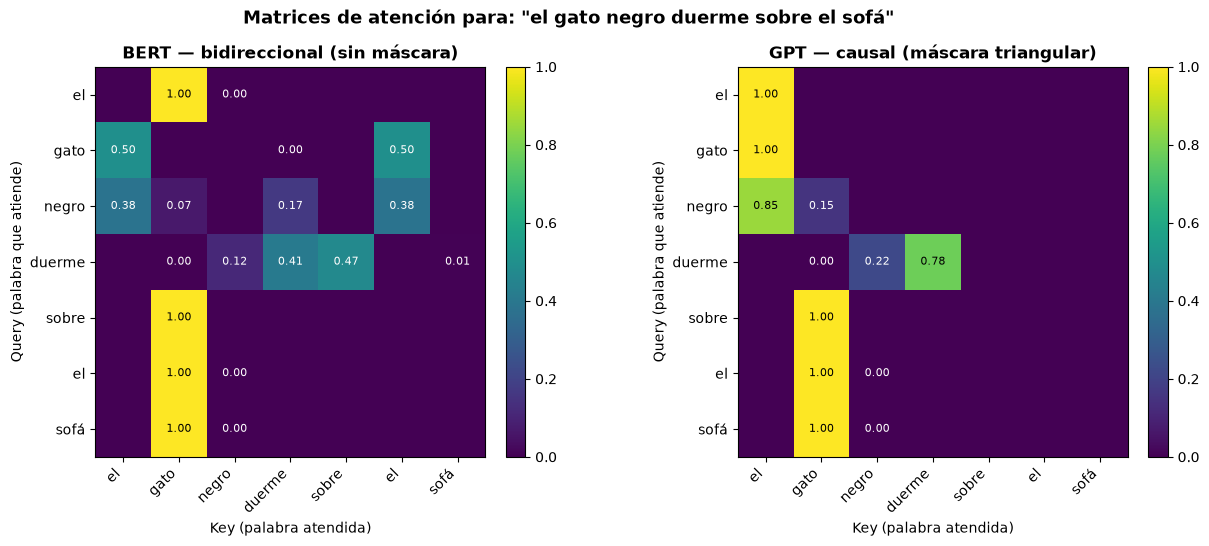

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, (A, titulo) in zip(axes, [(attn_bert, 'BERT — bidireccional (sin máscara)'),
                                  (attn_gpt,  'GPT — causal (máscara triangular)')]):
    im = ax.imshow(A, cmap='viridis', vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(tokens, rotation=45, ha='right')
    ax.set_yticks(range(n)); ax.set_yticklabels(tokens)
    ax.set_xlabel('Key (palabra atendida)')
    ax.set_ylabel('Query (palabra que atiende)')
    ax.set_title(titulo, fontweight='bold')
    for i in range(n):
        for j in range(n):
            if A[i, j] > 1e-6:
                ax.text(j, i, f'{A[i, j]:.2f}', ha='center', va='center',
                        color='white' if A[i, j] < 0.6 else 'black', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f'Matrices de atención para: "{oracion}"', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Relación semántica de las palabras

Para cada palabra (Query) mostramos a qué palabra le presta **más atención**, según cada modelo.

In [8]:
print(f'Oración: "{oracion}"\n')
print('== BERT (bidireccional) ==')
for i, w in enumerate(tokens):
    j = int(np.argmax(attn_bert[i]))
    print(f'  "{w}" atiende más a "{tokens[j]}" ({attn_bert[i, j]:.2f})')

print('\n== GPT (causal) ==')
for i, w in enumerate(tokens):
    j = int(np.argmax(attn_gpt[i]))
    print(f'  "{w}" atiende más a "{tokens[j]}" ({attn_gpt[i, j]:.2f})')

print('\nDimensión del vector de contexto -> BERT:', context_bert.shape, '| GPT:', context_gpt.shape)

Oración: "el gato negro duerme sobre el sofá"

== BERT (bidireccional) ==
  "el" atiende más a "gato" (1.00)
  "gato" atiende más a "el" (0.50)
  "negro" atiende más a "el" (0.38)
  "duerme" atiende más a "sobre" (0.47)
  "sobre" atiende más a "gato" (1.00)
  "el" atiende más a "gato" (1.00)
  "sofá" atiende más a "gato" (1.00)

== GPT (causal) ==
  "el" atiende más a "el" (1.00)
  "gato" atiende más a "el" (1.00)
  "negro" atiende más a "el" (0.85)
  "duerme" atiende más a "duerme" (0.78)
  "sobre" atiende más a "gato" (1.00)
  "el" atiende más a "gato" (1.00)
  "sofá" atiende más a "gato" (1.00)

Dimensión del vector de contexto -> BERT: (7, 16) | GPT: (7, 16)


## 7. Análisis comparativo BERT vs GPT

| Pregunta | **BERT (Encoder)** | **GPT (Decoder)** |
|---|---|---|
| **¿Cómo es la matriz de atención?** | **Densa y completa** (n×n): todas las celdas tienen peso > 0 porque no hay máscara. Cada fila suma 1. | **Triangular inferior**: la parte superior (futuro) es 0 por la máscara causal. Cada fila suma 1 sobre los tokens ≤ i. |
| **¿Existe algún orden secuencial como en los LSTMs?** | **No.** Todos los tokens se procesan en **paralelo**; no hay recurrencia ni dependencia temporal. El orden se aporta aparte (positional encoding). | **No hay recurrencia**, pero la **máscara impone un orden causal** (izquierda→derecha): un token no puede ver el futuro, imitando la generación secuencial sin el cuello de botella de los LSTMs. |
| **¿Cuál es la diferencia en la atención de las palabras?** | Cada palabra atiende a **todas** las demás (contexto izquierdo **y** derecho) a la vez. | Cada palabra atiende **solo a sí misma y a las anteriores**; nunca a las posteriores. |
| **¿Qué tipo de contexto capturan?** | Contexto **bidireccional / global**: el significado se enriquece con lo que está antes y después. | Contexto **unidireccional / autorregresivo**: solo el pasado, ideal para predecir el siguiente token. |
| **¿Para qué es ideal?** | Tareas de **comprensión**: clasificación de texto, análisis de sentimiento, NER, Q&A. | Tareas de **generación**: completar/generar texto, chatbots, modelos de lenguaje autorregresivos. |

## Conclusión

La misma ecuación de atención escalada de Vaswani produce dos comportamientos según la
**máscara $M$**: sin máscara (BERT) da atención **bidireccional** para *entender*; con máscara
causal (GPT) da atención **unidireccional** para *generar*. Todo esto sin recurrencia, con
cómputo paralelo sobre la matriz $QK^{T}$.